# Comportamiento de clientes NovaRetail+

## Contexto

*NovaRetail+* es un **e-commerce** en Latinoamérica con millones de usuarios.

Para el cierre del 2024, el equipo de **crecimiento y retención** quiere comprender `¿Qué factores de comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?`

Stack técnico:
- Jupyter Notebook
- Python (Pandas | Numpy | Seaborn | Scipy.stats | Matplotlib)

## Diccionario de datos

| Columna | Tipo de dato | Descripción | 
| - | - | - |
| id_cliente | string | Identificador único |
| edad | num | Edad del cliente |
| nivel_ingreso | num | Ingreso anual estimado del cliente |
| visitas_mes | num | Número de visitas a la app/web en el mes |
| compras_mes | num | Compras realizadas en el mes |
| gasto_publicidad_dirigida | num | Gastos en anuncios asignado al usuario |
| satisfaccion | num (1-5) | Clasificación de satisfacción |
| miembro_premium | 0/1 | Suscripción mensual (premium o no) |
| abandono | 0/1 | Si el cliente abandonó la plataforma |
| tipo_dispositivo | categórica | Móvil/Escritorio/Tablet |
| region | categórica | Norte/Sur/Este/Oeste |
| ingreso_anual | num | Ingreso anual del cliente a la empresa |

La métrica principal de análisis es **ingreso_anual**, utilizada para evaluar el impacto económico de los clientes.

## Exploración inicial de dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'..\Data\novaretail_comportamiento_clientes_2024.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


In [5]:
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


### Exploración de valores nulos

In [6]:
df.isna().sum()

id_cliente                   0
edad                         0
nivel_ingreso                0
visitas_mes                  0
compras_mes                  0
gasto_publicidad_dirigida    0
satisfaccion                 0
miembro_premium              0
abandono                     0
tipo_dispositivo             0
region                       0
ingreso_anual                0
dtype: int64

El dataset no tiene valores nulos, indicando que todas las columnas están llenas posiblemente de manera correcta.

## Preparación de datos y documentación de supuestos

### Variables numéricas

In [7]:
df[['edad', 'nivel_ingreso', 'ingreso_anual', 'visitas_mes', 'compras_mes', 
    'gasto_publicidad_dirigida']].describe()

,edad,nivel_ingreso,ingreso_anual,visitas_mes,compras_mes,gasto_publicidad_dirigida
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,36.594180,10.029000,1.206467,20.149301
std,11.492378,9833.166305,34.484888,3.158189,1.105284,10.880724
min,18.000000,8000.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,23127.097500,0.000000,8.000000,0.000000,12.310000
50%,38.000000,30023.745000,30.705000,10.000000,1.000000,19.730000
75%,46.000000,36768.440000,58.220000,12.000000,2.000000,27.292500
max,75.000000,74790.840000,244.690000,25.000000,8.000000,75.510000


- **Edad**: Existe un rango de edad posible y lógico para un usuario de e-commerce en Latinoamérica, con la mayoría de edad en 18 años y con una edad máxima de 75 años.

    Al ser edad un número entero, se procederá a cambiar el tipo de dato de *float* a *int*
- **Nivel de ingreso**: El valor mínimo de ingreso anual es a simple vista más bajo que el 1er cuartil, sin embargo, es un valor posible en Latinoamérica.

    El rango de ingresos es considerablemente extenso, pero posible de acuerdo a los rangos salariales existentes en múltiples países latinoamericanos.
- **Ingreso anual**: El ingreso anual que le da un cliente a la empresa arranca con un mínimo hasta el 1er cuartil con un valor 0, indicando que existen usuarios que no han realizado ninguna compra por el momento y en consecuencia, no han generado ningún ingreso.

- El 50% de usuarios generan para la empresa abajo de $30.7 usd, mientras el máximo es de $244.7 usd, reflejando posibles patrones de consumo en relación al nivel de ingreso y edad.

- **Visitas por mes**: La visita mínima es de al menos 1 vez, mientras que tenemos usuarios que alcanzan las 25 visitas mensuales, es posible que la cantidad de visitas influya en la *cantidad de compras realizadas mensualmente*, al igual que el *nivel de ingreso o la edad*.

- **Compras por mes**: Al igual que ingreso anual, el valor mínimo y valores debajo del 25% se ubican en 0 compras mensuales, ubicando valores debajo del 50% en una compra mensual y un máximo de hasta 8.

- **Gasto publicitario dirigido**: El gasto publicitario dirigido al usuario aclara que no se realiza a todos los usuarios, teniendo como valor mínimo $0 usd, sin embargo, sí se llega a valores considerablemente elevados de $75.5 usd, siendo posibles outliers.

In [8]:
df['edad'].unique()

array([44., 36., 46., 56., 35., 57., 47., 32., 45., 41., 18., 31., 26.,
       42., 27., 21., 39., 24., 43., 34., 60., 38., 25., 48., 23., 22.,
       40., 37., 20., 29., 51., 33., 30., 50., 49., 28., 54., 61., 68.,
       52., 55., 64., 19., 71., 75., 66., 59., 63., 53., 58., 62., 65.,
       67., 69., 70., 73., 74., 72.])

In [9]:
df['edad'] = df['edad'].astype(int)

In [10]:
df['edad'].unique()

array([44, 36, 46, 56, 35, 57, 47, 32, 45, 41, 18, 31, 26, 42, 27, 21, 39,
       24, 43, 34, 60, 38, 25, 48, 23, 22, 40, 37, 20, 29, 51, 33, 30, 50,
       49, 28, 54, 61, 68, 52, 55, 64, 19, 71, 75, 66, 59, 63, 53, 58, 62,
       65, 67, 69, 70, 73, 74, 72])

### Variables categóricas

#### Tipos de dispositivos

In [12]:
df['tipo_dispositivo'].value_counts()

tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64

De manera inicial, contamos con 3 dispositivos usados por los usuarios (móvil, escritorio y tablet), del cual predomina el uso del móvil como dispositivo para acceder a la app/web con un 65% de participación

#### Región

In [13]:
df['region'].value_counts()

region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64

La región **norte** tiene mayor participación con 29% del total, seguido del oeste con 25% de participación

#### Tipos de dispositivos por región

In [14]:
df[['tipo_dispositivo', 'region']].value_counts()

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
Name: count, dtype: int64

El dispositivo móvil domina en las 4 regiones de Latinoamérica seguido por las computadoras de escritorio, indicando una preferencia por la practicidad y versatilidad del dispositivo móvil para realizar múltiples actividades, entre ellas, ingresar a la app/web y realizar compras

#### Exploración de variables binarias

In [15]:
df[['miembro_premium', 'abandono']].value_counts()

miembro_premium  abandono
0                0           10741
                 1            2170
1                0            1998
                 1              91
Name: count, dtype: int64

Predominan los miembros básicos sobre los premium; posiblemente, debido a esa proporción, se observa una mayor cantidad de abandonos respecto a los miembros premium

#### Outliers

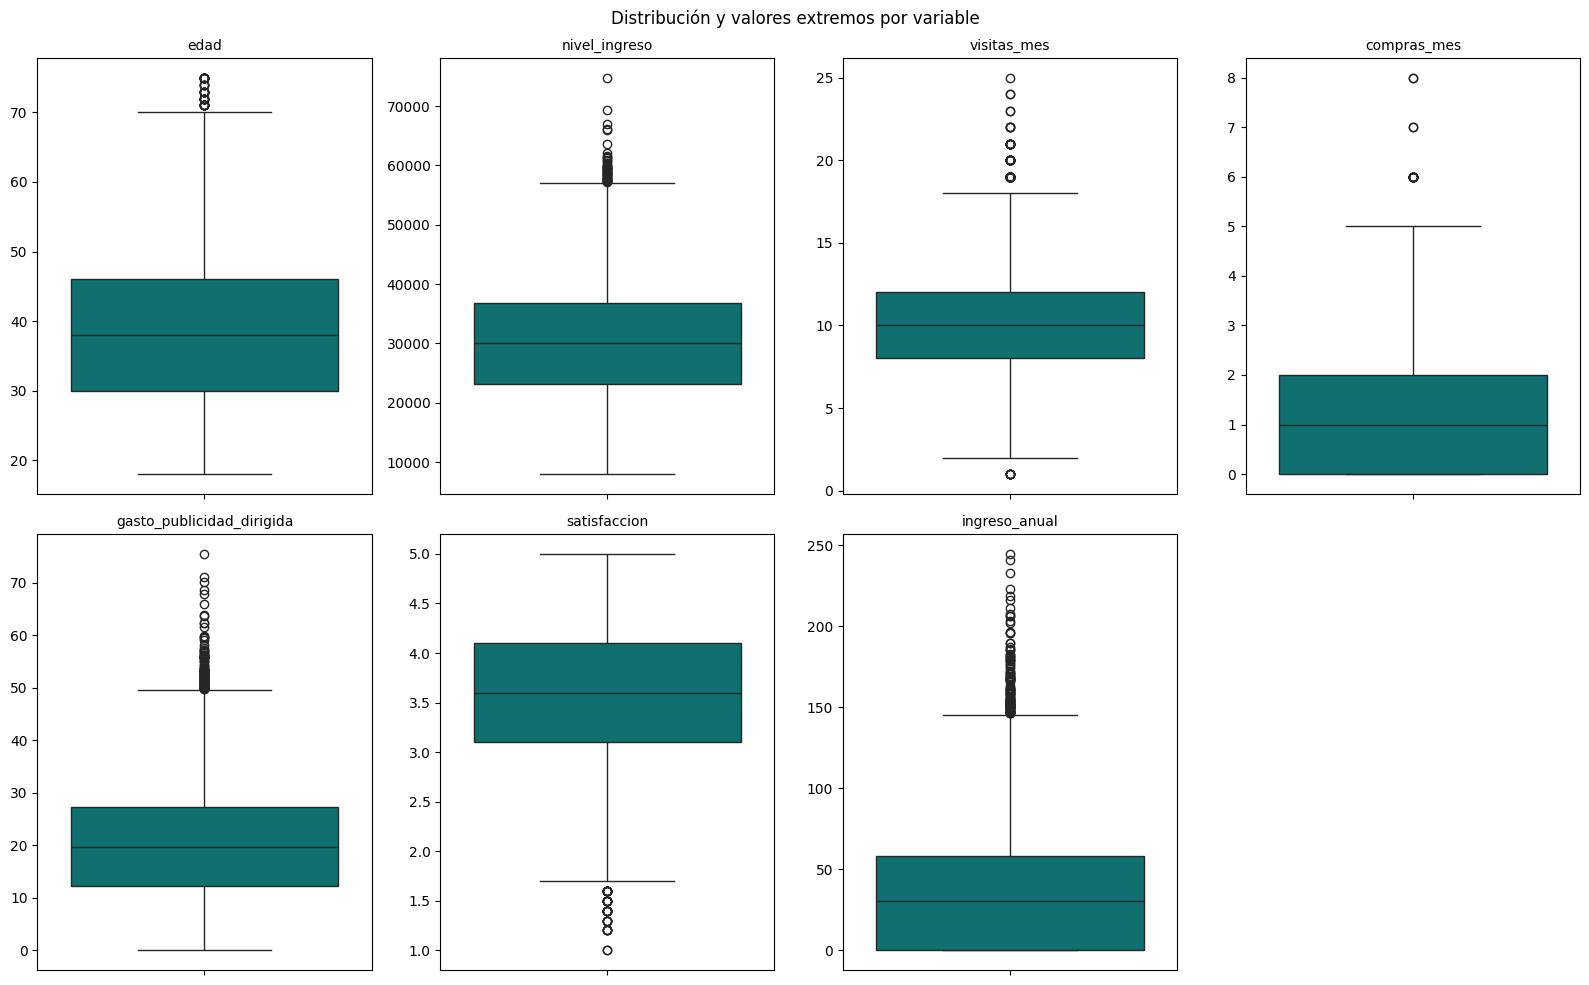

In [16]:
num = ['edad','nivel_ingreso','visitas_mes','compras_mes',
       'gasto_publicidad_dirigida','satisfaccion','ingreso_anual']

fig, axes = plt.subplots(2, 4, figsize=(16,10))
for ax , c in zip(axes.flat, num):
    sns.boxplot(y= df[c], ax= ax, color= 'teal')
    ax.set_title(c, fontsize=10)
    ax.set_ylabel('')
axes.flat[-1].axis('off')   # apaga el 8º cuadro vacío
plt.suptitle('Distribución y valores extremos por variable', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
for c in num:
    q1, q3 = df[c].quantile([.25, .75])
    iqr = q3 - q1
    n_out = ((df[c] < q1 - 1.5*iqr) | (df[c] > q3 + 1.5*iqr)).sum()
    print(f"{c}: {n_out} ({n_out/len(df)*100:.2f}%)")

edad: 54 (0.36%)
nivel_ingreso: 44 (0.29%)
visitas_mes: 118 (0.79%)
compras_mes: 24 (0.16%)
gasto_publicidad_dirigida: 103 (0.69%)
satisfaccion: 45 (0.30%)
ingreso_anual: 114 (0.76%)


Las variables presentan valores extremos (menor o igual a 0.8% por variable según el criterio IQR 1.5×), concentrados en las colas altas de las distribuciones sesgadas: corresponden a clientes de alto volumen, mayor número de visitas, compras e ingreso generado y no a errores de captura, ya que se mantienen dentro de rangos plausibles. Por ello se conservan en el análisis. La similitud entre Pearson y Spearman (confirmada más adelante) verifica que estos extremos no distorsionan las asociaciones reportadas.

Con una muestra de 15,000 observaciones, los valores p pequeños son esperables incluso para efectos triviales, por lo que la interpretación se basa en el tamaño del efecto, no en la importancia estadística.

Por ejemplo, la relación premium con ingreso resulta significativa (p≈0) pero su coeficiente (r=0.09) la vuelve irrelevante en la práctica.

## Supuestos

- Se realizará el análisis utilizando todo el conjunto de datos disponible.
- Datos no presentan errores, están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

### Visualización de relaciones

Representación visual para identificar relaciones entre variables numéricas

#### Heatmap

In [18]:
df.nunique()
df_num_corr= df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']].corr()

<Axes: >

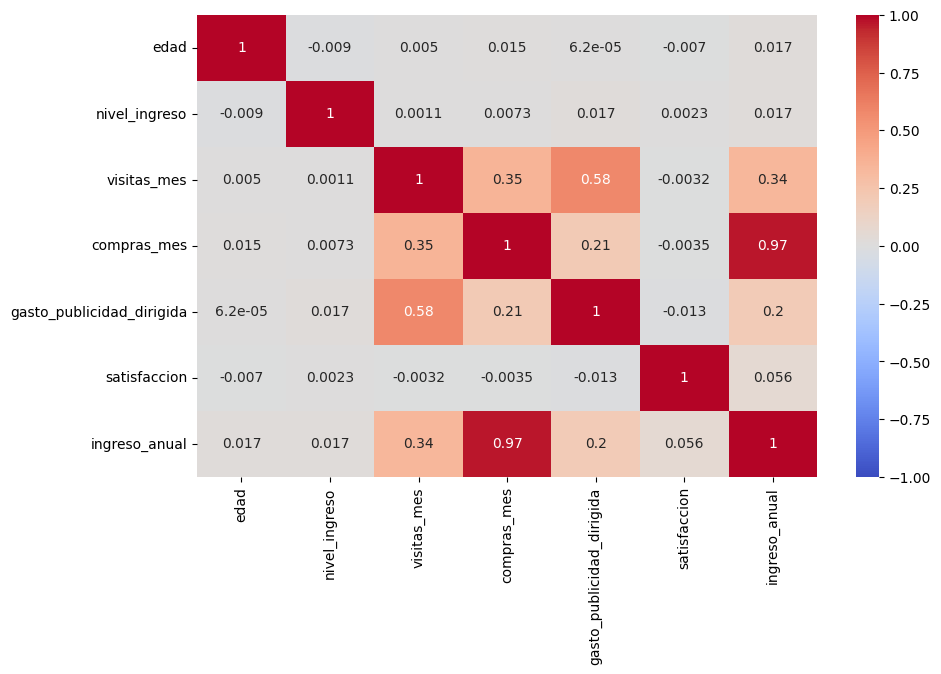

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_num_corr,
            annot=True,      # Muestra coeficientes dentro del heatmap
            cmap='coolwarm', # Cambia la paleta de colores
            center=0,        # El valor central de la escala es 0 (blanco/gris)
            vmin=-1,         # FUERZA el límite inferior a -1 (Azul absoluto)
            vmax=1           # FUERZA el límite superior a +1 (Rojo absoluto)
            )

- No se aprecian correlaciones negativas considerables, por lo que ningún espacio se pinta de azul.
- **Gastos publicitarios dirigidos** tiene una correlación positiva moderada con **visitas mensuales** indicando que existe una posible correlación entre estos.
- **Compras mensuales** tienen una correlación débil con **visitas mensuales**, lo cual tiene sentido debido a que mientras más visitas se realicen al mes es probable que se realicen más compras.
- **Gastos publicitarios dirigidos** tienen una correlación débil con **compras mensuales**, posiblemente indicando que la publicidad podría provocar acción de compra.
- **Ingreso anual** y **compras mensuales** tienen una correlación casi perfecta (coeficiente 0.967). Esto no refleja una relación de comportamiento, sino una **relación mecánica**: `ingreso_anual ≈ 30 × compras_mes`, donde ~30 es el precio promedio por compra. Es decir, `compras_mes` no es un *driver* del ingreso; es el ingreso mismo en otra unidad. Por lo tanto, los drivers de comportamiento relevantes para el negocio son las variables *río arriba* de la compra (visitas y publicidad), no `compras_mes`.
- **Ingreso anual** tiene correlación débil con **visitas mensuales** y con **gastos publicitarios dirigidos**, sus coeficientes son cercanos entre sí.

#### Scatterplot para variables clave

Al existir múltiples variables con correlaciones prácticamente nulas, no tiene sentido que se realice un scatterplot general, sería únicamente ruido innecesario en el proceso de análisis.

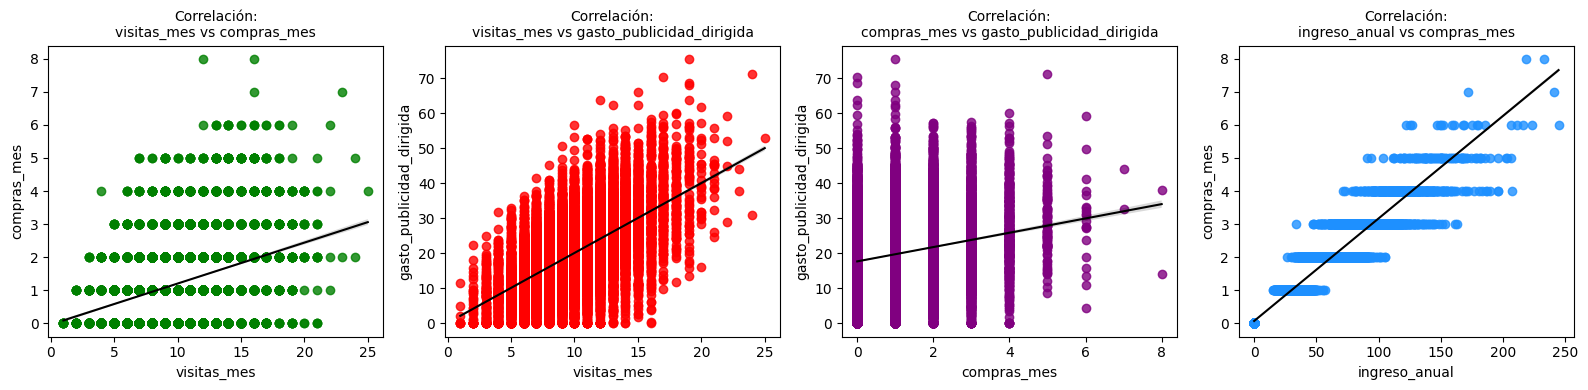

In [20]:
# 1. Definimos la lista de los pares de variables que queremos analizar y su color
key_cols = [
    ("visitas_mes", "compras_mes", "green"),
    ("visitas_mes", "gasto_publicidad_dirigida", "red"),
    ("compras_mes", "gasto_publicidad_dirigida", "purple"),
    ("ingreso_anual", "compras_mes", "dodgerblue")
]

# 2. Creamos el lienzo
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 3. Iteramos automáticamente sobre nuestra lista y los ejes
for i, (col_x, col_y, color_elegido) in enumerate(key_cols):
    
    # Seaborn asigna AUTOMÁTICAMENTE el nombre de col_x a xlabel y col_y a ylabel
    sns.regplot(data=df, x=col_x, y=col_y, ax=axes[i], color=color_elegido,
                line_kws={"color": "black", "linewidth": 1.5}) # Línea de tendencia sutil
    
    # El título también se genera en automático usando los nombres de las variables
    axes[i].set_title(f"Correlación:\n{col_x} vs {col_y}", fontsize=10)

plt.tight_layout()
plt.show()

- Todas las correlaciones son positivas.
- Compras al mes muestran un comportamiento prácticamente idéntico al ingreso, ya que, mientras más compras realice cada cliente, aumentará la cantidad de ingresos que le generará a la empresa en el año (relación mecánica, no de comportamiento).
- **Gastos publicitarios dirigidos** muestran una posible relación con la **cantidad de visitas** y la **cantidad de ventas mensuales**.
- Estas variables covarían entre sí, pero con datos observacionales no es posible afirmar la dirección: no se puede concluir que el aumento de **gastos publicitarios dirigidos** provoque más **visitas** ni más **compras**. Queda como hipótesis a validar.

### Coeficientes de correlación y evidencias numéricas

Se reportan coeficientes que respaldan los patrones observados utilizando **Pearson/Spearman**, **Cramér's V** y **Punto-biserial**

#### Pearson/Spearman

In [21]:
key_pairs = [
    ("visitas_mes", "compras_mes"),
    ("visitas_mes", "gasto_publicidad_dirigida"),
    ("compras_mes", "gasto_publicidad_dirigida"),
    ("ingreso_anual", "compras_mes")
]
resultados = []

for col_x, col_y in key_pairs:
    pearson_val = df[col_x].corr(df[col_y], method='pearson')
    spearman_val=df[col_x].corr(df[col_y], method='spearman')

    resultados.append({
        'Variable X': col_x,
        'Variable Y': col_y,
        'Pearson (Lineal)': pearson_val,
        'Spearman (Monótona)': spearman_val
    })

correlaciones = pd.DataFrame(resultados)

In [22]:
# importación de jinja2 para estilizar la tabla
import jinja2 as jnj

tabla_estilizada = correlaciones.style.background_gradient(
    cmap='Blues', 
    subset=['Pearson (Lineal)', 'Spearman (Monótona)']
)

display(tabla_estilizada)

,Variable X,Variable Y,Pearson (Lineal),Spearman (Monótona)
0,visitas_mes,compras_mes,0.353844,0.332943
1,visitas_mes,gasto_publicidad_dirigida,0.578947,0.559267
2,compras_mes,gasto_publicidad_dirigida,0.207528,0.192511
3,ingreso_anual,compras_mes,0.967149,0.967482


- Confirmamos de esta manera que **compras mensuales** e **ingreso anual** reflejan el mismo comportamiento con ambos coeficientes casi perfectos (0.967)
- **Gastos publicitarios** y **visitas mensuales** covarían de forma directa y positiva (0.578). Con datos observacionales no es posible afirmar la dirección: la publicidad podría estar generando visitas, o a los usuarios más activos se les podría estar asignando mayor presupuesto. Queda como hipótesis a validar, no como relación causal.
- La correlación entre **visitas mensuales** y **compras mensuales** refleja una correlación directa positiva, pero débil (0.353); la información indica un posible cuello de botella en el momento de compra, ya que el que la gente visite la página web no es garantía de compra.
- **Compras mensuales** y **gastos publicitarios dirigidos** tienen una correlación débil; esto posiblemente se deba a que el *funnel* sea acceder de forma orgánica o por publicidad, efectuar la visita a la plataforma y posteriormente realizar la o las compras.

In [23]:
# Se crea una columna "compro" indicando que el usuario ha comprado al menos una vez
df['compro'] = (df['compras_mes'] > 0).astype(int)

# (a) Tamaño de cada grupo
print("No compradores ($0):", round((df['compro']==0).mean()*100, 2), "%")

# '¿Qué distingue a quien compra de quien no?'
display(df.groupby('compro')[['visitas_mes','gasto_publicidad_dirigida',
                       'satisfaccion','nivel_ingreso','edad']].mean().round(2))

# (c) Entre compradores, ¿qué explica el MONTO (más allá de precio × cantidad)?
pur = df[df['compro']==1]
for c in ['visitas_mes','gasto_publicidad_dirigida','satisfaccion','nivel_ingreso','edad']:
    print(c, round(pur[c].corr(pur['ingreso_anual']), 3))

No compradores ($0): 30.45 %


,visitas_mes,gasto_publicidad_dirigida,satisfaccion,nivel_ingreso,edad
compro,,,,,
0,8.84,17.84,3.6,29909.55,37.90
1,10.55,21.16,3.6,30067.92,38.42


visitas_mes 0.28
gasto_publicidad_dirigida 0.166
satisfaccion 0.096
nivel_ingreso 0.021
edad 0.005


Los compradores tienen más publicidad dirigida y covarían con más visitas mensuales; sin embargo, la satisfacción es la misma y el nivel de ingreso y la edad son casi similares. Esto nos da un posible indicio de que lo ideal sería convertir a ese 30% de usuarios que no han comprado artículos, en lugar de buscar exprimir más a los usuarios que ya compran. Entre quienes ya compran, solo las visitas predicen débilmente el monto (0.28).

In [24]:
# Embudo de venta
df['bin_visitas'] = pd.cut(df['visitas_mes'], [0, 6, 9, 12, 25])
df.groupby('bin_visitas', observed=True).agg(
    tasa_compra=('compro','mean'),
    compras_prom=('compras_mes','mean'),
    ingreso_prom=('ingreso_anual','mean'),
    num_clientes=('compro','size')).round(2)

,tasa_compra,compras_prom,ingreso_prom,num_clientes
bin_visitas,,,,
"(0, 6]",0.47,0.58,17.88,1882
"(6, 9]",0.64,0.99,30.33,4966
"(9, 12]",0.74,1.29,39.01,4934
"(12, 25]",0.84,1.78,53.50,3218


Los usuarios que visitan más de 12 veces tienen una conversión del 84%, a comparación del 47% de los usuarios que visitan menos de 6 veces, y triplica el ingreso promedio, posicionando las visitas como una palanca accionable principal.

In [25]:
from scipy.stats import kruskal

for cat in ['tipo_dispositivo', 'region']:
    print(df.groupby(cat)['ingreso_anual'].agg(['mean','median']).round(2))
    grupos = [g['ingreso_anual'].values for _, g in df.groupby(cat)]
    print(cat, "Kruskal p =", round(kruskal(*grupos)[1], 4), "\n")

                   mean  median
tipo_dispositivo               
escritorio        36.42   30.44
móvil             36.59   30.69
tablet            37.07   31.34
tipo_dispositivo Kruskal p = 0.4991 

         mean  median
region               
este    36.89   30.78
norte   36.71   30.72
oeste   35.72   30.36
sur     37.10   30.94
region Kruskal p = 0.4481 



El tipo de dispositivo y la región no muestran evidencia de influir en el ingreso (Kruskal p=0.50 y p=0.45; no se rechaza H0). Las distribuciones por grupo son estadísticamente indistinguibles.

#### Punto-biserial

En este coeficiente calcularemos la correlación de las variables binarias (abandono y miembro premium) con las variables clave que se usaron anteriormente.

In [26]:
# importamos poinbiserial de scipy.stats
from scipy.stats import pointbiserialr

In [27]:
variables_clave = ['visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'ingreso_anual']
booleanas = ['miembro_premium', 'abandono']

resultados_biserial = []

for var_bool in booleanas:
    for var_num in variables_clave:
        r, p = pointbiserialr(df[var_bool], df[var_num])

        resultados_biserial.append({
            'Variable booleana (0/1)':var_bool, 
            'Variable numérica': var_num, 
            'Correlación Punto-biserial': round(r, 3), 
            'Valor P': round(p, 3)})

pb_corr = pd.DataFrame(resultados_biserial)

In [28]:
tabla_biserial_estilizada = pb_corr.style.background_gradient(
    cmap='Blues', 
    subset=['Correlación Punto-biserial']
)

display(tabla_biserial_estilizada)

,Variable booleana (0/1),Variable numérica,Correlación Punto-biserial,Valor P
0,miembro_premium,visitas_mes,-0.013000,0.121000
1,miembro_premium,compras_mes,0.003000,0.674000
2,miembro_premium,gasto_publicidad_dirigida,0.003000,0.739000
3,miembro_premium,ingreso_anual,0.093000,0.000000
4,abandono,visitas_mes,-0.009000,0.273000
5,abandono,compras_mes,0.008000,0.310000
6,abandono,gasto_publicidad_dirigida,-0.005000,0.574000
7,abandono,ingreso_anual,-0.003000,0.729000


In [29]:
pointbiserialr(df['miembro_premium'], df['abandono'])

SignificanceResult(statistic=np.float64(-0.12048783398715414), pvalue=np.float64(1.2730798507362647e-49))

In [30]:
pointbiserialr(df['abandono'], df['satisfaccion'])

SignificanceResult(statistic=np.float64(-0.023832560673804026), pvalue=np.float64(0.0035109768933622915))

- El *p-value* nos indica que **los resultados no son estadísticamente significativos** (>0.05), diciéndonos que cualquier correlación aparente podría ser mera casualidad, a excepción de **miembros premium** con **ingreso anual**.
- **Miembros premium** con **ingreso anual** da una correlación muy débil (0.093), sugiriendo que ser miembro premium podría no garantizar un ingreso anual considerable.
- No existe una correlación sólida como tal entre el resto de variables, los coeficientes de correlación no superan el 0.008

Cramér's V

Recordemos que V de Cramér se utiliza para analizar correlación entre tipos de variables categóricas. En este caso analizaremos **tipo de dispositivo** y **región**

In [31]:
# importación de chi2_contingency para tablas de contingencia
from scipy.stats import chi2_contingency

In [32]:
def calc_cramers_v(df, var1, var2):
    for v1 in var1:
        for v2 in var2:
            # Tabla de contingencia (cruzamos filas y columnas)
            contingency_tab=pd.crosstab(df[v1], df[v2])

            # Cálculo chi-cuadrado
            chi2, p, dof, expected= chi2_contingency(contingency_tab)

            # Tabla de observaciones
            n = contingency_tab.sum().sum()

            # Prevención de división por cero
            min_dim = min(contingency_tab.shape) - 1
            if min_dim <= 0:
                continue

            # Cálculo de Cramer's-V (Corrección de sintaxis aquí)
            cramers_v = np.sqrt(chi2 / (n * min_dim))

            print(f'{v1} vs {v2}: {cramers_v:.3f}')
    

In [33]:
var1 = ['tipo_dispositivo', 'region']
var2 = ['miembro_premium', 'abandono', 'region', 'tipo_dispositivo']

In [34]:
calc_cramers_v(df, var1, var2)

tipo_dispositivo vs miembro_premium: 0.020
tipo_dispositivo vs abandono: 0.007
tipo_dispositivo vs region: 0.012
tipo_dispositivo vs tipo_dispositivo: 1.000
region vs miembro_premium: 0.013
region vs abandono: 0.015
region vs region: 1.000
region vs tipo_dispositivo: 0.012


- No se aprecian asociaciones relevantes entre las variables categóricas (*tipo de dispositivo* y *región*) y variables booleanas (*miembros premium* y *abandonos*)
- Los datos sugieren que el tipo de dispositivo y la región no tienen un efecto real en el comportamiento de los ingresos anuales para la empresa.

## Interpretación de resultados para NovaRetail+

### Hallazgos

1. Se comprobó que *compras_mes* no es un driver de comportamiento, es el ingreso anual en otra unidad (Pearson y Spearman casi idénticos, r= 0.967).
2. El caso tiene dos partes:
    - Conversión: ¿el cliente llega a comprar? Segmento decisivo, el 30% no compra.
    - Intensidad: entre quienes compran, ¿cuánto gastan? Explicada casi solo por la frecuencia de visitas (0.28).
3. El tráfico es el driver de comportamiento más fuerte junto con la publicidad y son los únicos que distinguen a los compradores de los no compradores
4. Edad, región, tipo de dispositivo, plan premium, satisfacción son variables que no mueven el ingreso (null result). Es un hallazgo contraintuitivo para el equipo de retención

### Interpretaciones

1. El mayor impacto sería lograr la conversión del 30% de usuarios inactivos/no compradores en lugar de aumentar el gasto publicitario dirigido a los usuarios que ya compran.
2. Las visitas son el correlato de comportamiento más fuerte de la conversión. Esto sugiere que estrategias para elevar el tráfico de los usuarios inactivos podrían aumentar su conversión. La vía recomendada sería un experimento controlado (A/B) antes de asumir causalidad.
3. Premium y satisfacción no se asocian con mayor ingreso, asumir que impulsan retención no está respaldado por los datos.

### Limitaciones

- Correlación no es causalidad, son datos observacionales.
- Visitas y publicidad no son palancas independientes, la dirección no se puede afirmar.
- Compras e ingreso es un artefacto de diseño del dataset, no un insight de negocio
- Dataset limitado a una muestra de 15,000 usuarios sin estacionalidad

### **Próximos pasos** 

1. Validar causalidad de visitas mediante experimento controlado
    - Diseñar un test A/B donde a un grupo de usuarios inactivos (los del 30%) se les incremente el tráfico dirigido, y comparar su tasa de conversión contra un grupo control.

2. Incorporar variables de comportamiento faltantes
    - Recencia: días desde la última visita o compra (distinguiría inactivos temporales de inactivos crónicos).
    - Fuente de tráfico: orgánico vs pagado (resolvería la ambigüedad de dirección entre publicidad y visitas).
    - Abandono de carrito: identificaría si el cuello de botella está en la intención de compra o en el checkout.

3. Construir un modelo predictivo de conversión
    - Con las variables identificadas como relevantes (visitas, publicidad), entrenar un modelo de clasificación binaria (regresión logística como baseline) para predecir qué usuarios inactivos tienen mayor probabilidad de convertir.
